# 🏠 House Price Prediction

## Project Overview

This project aims to develop a machine learning model that predicts the sale prices of residential houses based on their physical characteristics, location, and other property-related features. The project follows a complete machine learning workflow, including Exploratory Data Analysis (EDA), Data Preprocessing, Feature Engineering, Model Development, Model Evaluation, and Deployment.

---

# Dataset Documentation

## Dataset Name

House Prices - Advanced Regression Techniques

## Dataset Source

Kaggle: House Prices - Advanced Regression Techniques

## Problem Statement

The objective is to predict the final sale price (`SalePrice`) of residential properties using various numerical and categorical features describing each house.

## Dataset Summary

| Attribute | Value |
|-----------|-------|
| Number of Records | 1460 |
| Number of Features | 81 (including target) |
| Target Variable | `SalePrice` |
| Numerical Features | 38 |
| Categorical Features | 43 |

## Dataset Characteristics

- Mixed numerical and categorical features.
- Missing values are present in several columns.
- The target variable is positively skewed.
- Some numerical features contain potential outliers.
- The dataset contains information related to the physical and qualitative characteristics of residential properties.

## Project Workflow

1. Exploratory Data Analysis (EDA)
2. Data Preprocessing
3. Feature Engineering
4. Model Training
5. Model Evaluation
6. Model Deployment

---

# Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/train.csv")

## 1. Dataset Shape

In this section, we inspect the size of the dataset by checking the number of rows and columns.

In [4]:
df.shape

(1460, 81)

## 2. Preview the Dataset

In this section, we display the first five rows of the dataset to understand the structure of the data and inspect the available features.


In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. View Column Names

In this section, we display all the column names to understand the available features in the dataset.

In [6]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## 4. Dataset Information

In this section, we inspect the structure of the dataset.

We will examine:
- Total number of entries
- Number of non-null values
- Data types of each feature
- Memory usage

This helps us identify missing values and understand which features are numerical or categorical.

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 5. Statistical Summary

In this section, we generate summary statistics for all numerical features.

The statistics include:
- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

These statistics help us understand the distribution of the data and identify possible outliers.

In [8]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 6. Missing Value Analysis

In this section, we identify missing values in the dataset.

Missing values are important because many machine learning algorithms cannot work with incomplete data.

We will determine which features contain missing values and how many missing values each feature has.

In [9]:
df.isnull().sum()


Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [10]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]


LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains no duplicate records (`0` duplicate rows). Therefore, no duplicate removal is required, and each row represents a unique observation.

In [12]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [13]:
df.describe(include='object')

C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


### Observation

The categorical columns contain information such as property features and furnishing status. The summary shows the number of unique categories and the most frequent value for each categorical feature. This information will help during categorical encoding in the preprocessing stage.

In [14]:
categorical_columns = df.select_dtypes(include='object').columns

categorical_columns

C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\4261840568.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [15]:
len(categorical_columns)

43

In [16]:
for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


MSZoning
<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Street
<StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Alley
<StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str

LotShape
<StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str

LandContour
<StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str

Utilities
<StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str

LotConfig
<StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str

LandSlope
<StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str

Neighborhood
<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Condition1
<StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', '

### Observation

The dataset contains multiple categorical features representing property characteristics such as zoning, neighborhood, building type, roofing, garage type, and sale condition. Each feature has its own set of categories that will need to be encoded into numerical values during the preprocessing stage before training machine learning models.

In [17]:
for column in categorical_columns:
    print(f"\n{'='*50}")
    print(f"Column: {column}")
    print(df[column].value_counts(dropna=False))


Column: MSZoning
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Column: Street
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Column: Alley
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Column: LotShape
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Column: LandContour
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Column: Utilities
Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

Column: LotConfig
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

Column: LandSlope
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Column: Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSid

### Observation

The frequency distribution of the categorical features shows that some categories occur much more frequently than others. Certain features also contain missing values, which will need to be handled during preprocessing. Understanding these distributions helps determine suitable encoding and data cleaning strategies.

In [18]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [19]:
len(numerical_columns)

38

In [20]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


### Observation

The numerical summary provides descriptive statistics such as the mean, standard deviation, minimum, maximum, and quartiles for each numerical feature. These statistics help identify the scale and variability of each feature and provide an initial indication of potential outliers or unusual values.

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

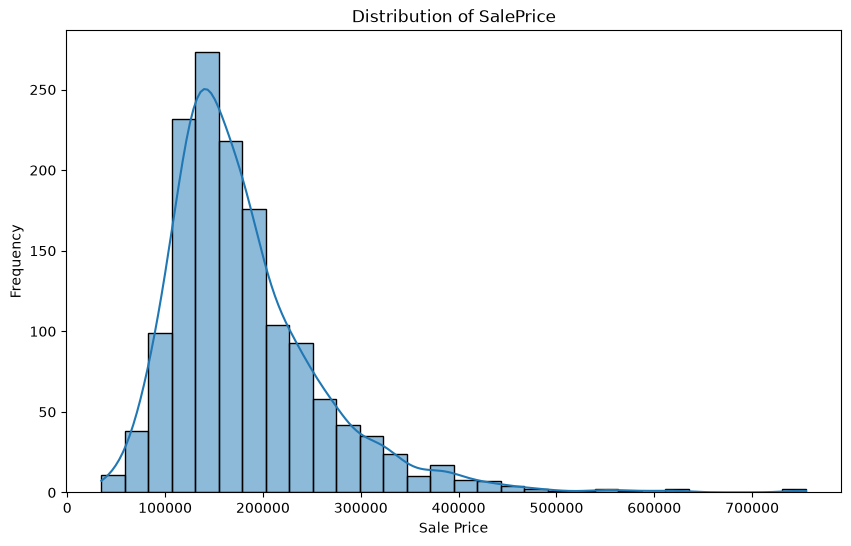

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], bins=30, kde=True)

plt.title("Distribution of SalePrice")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The distribution of the target variable (`SalePrice`) is positively (right) skewed. Most houses have sale prices between approximately 100,000 and 200,000, while a small number of houses have significantly higher prices, creating a long right tail. These high-priced properties may represent outliers. A log transformation may be considered later during preprocessing if required by the selected machine learning model.

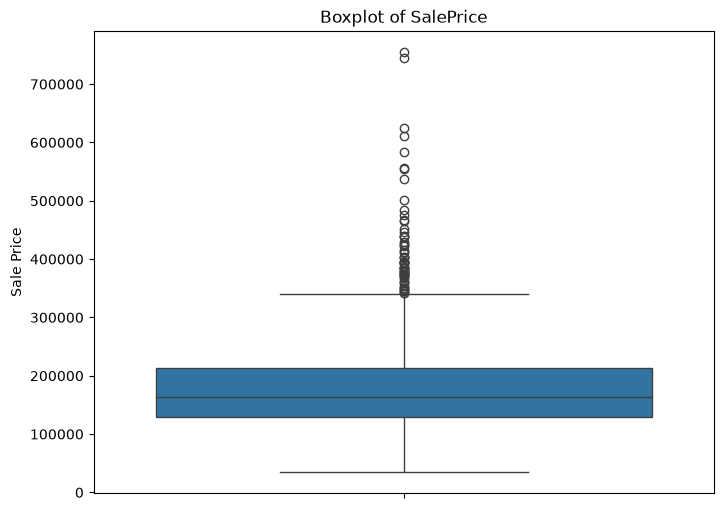

In [23]:
plt.figure(figsize=(8, 6))

sns.boxplot(y=df['SalePrice'])

plt.title("Boxplot of SalePrice")
plt.ylabel("Sale Price")

plt.show()

### Observation

The boxplot of `SalePrice` shows that the dataset contains several high-value outliers above the upper whisker, indicating that a small number of houses are significantly more expensive than the majority. The median lies near the center of the box, while no significant lower outliers are observed. These outliers appear to be genuine observations and will be considered carefully during preprocessing rather than being removed immediately.

In [24]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()

correlation_matrix

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,...,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,0.012609,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,-0.012713,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,-0.021998,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,-0.050298,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.005024,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420


## Correlation Heatmap

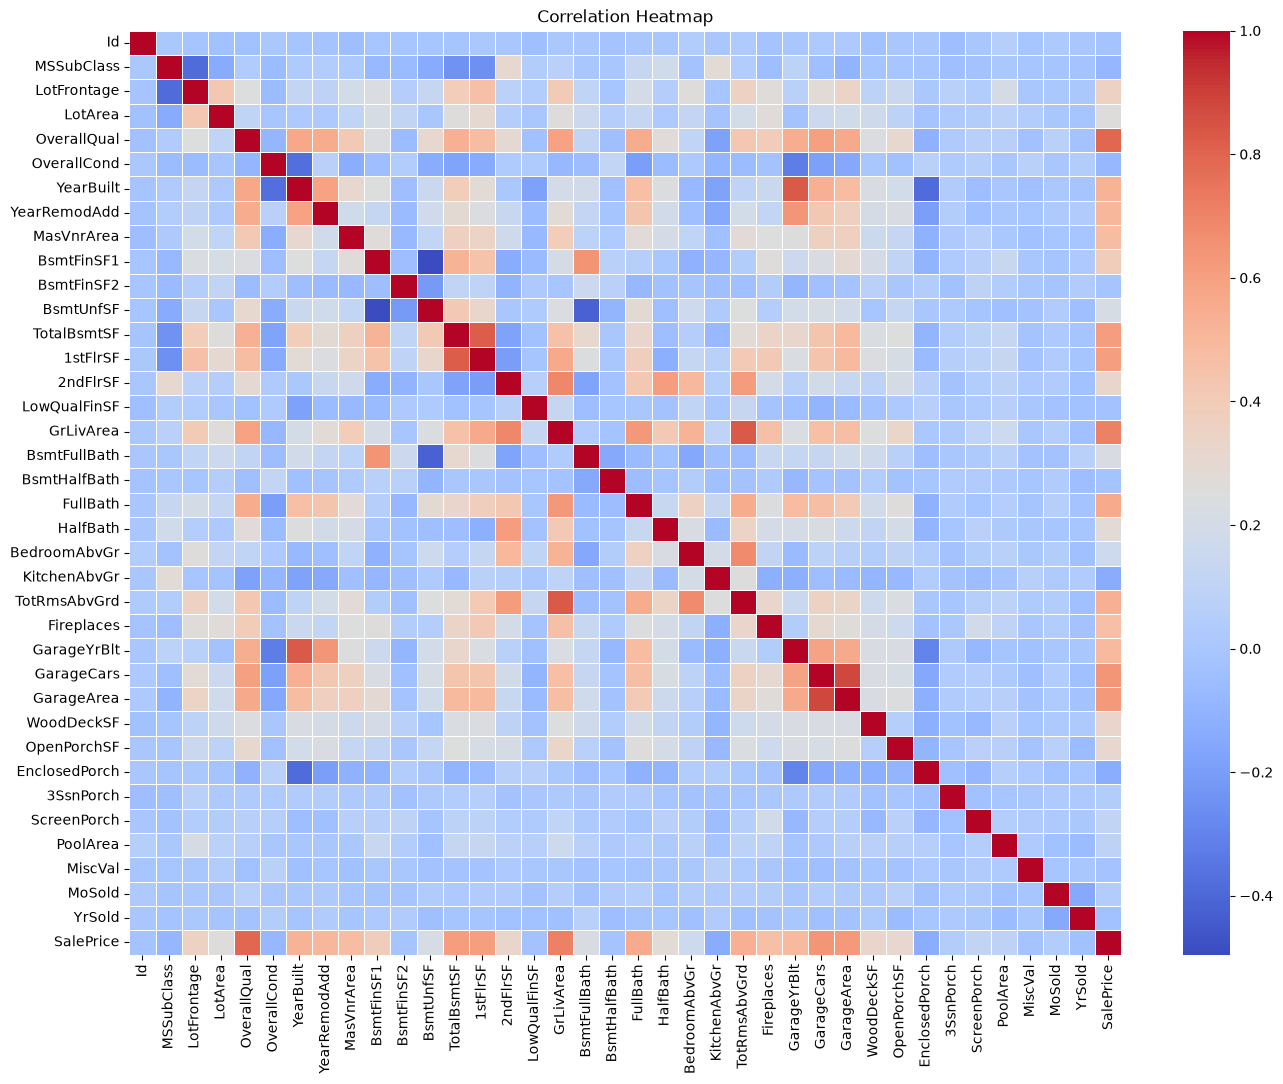

In [25]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

## Features Most Correlated with SalePrice

In [26]:
saleprice_corr = correlation_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Observation

The correlation analysis shows that **OverallQual**, **GrLivArea**, **GarageCars**, **GarageArea**, and **TotalBsmtSF** have the strongest positive relationships with **SalePrice**. This suggests that the overall quality of the house, its living area, garage capacity, garage size, and basement size are among the most influential numerical features for predicting house prices. These features are expected to play an important role during model training.

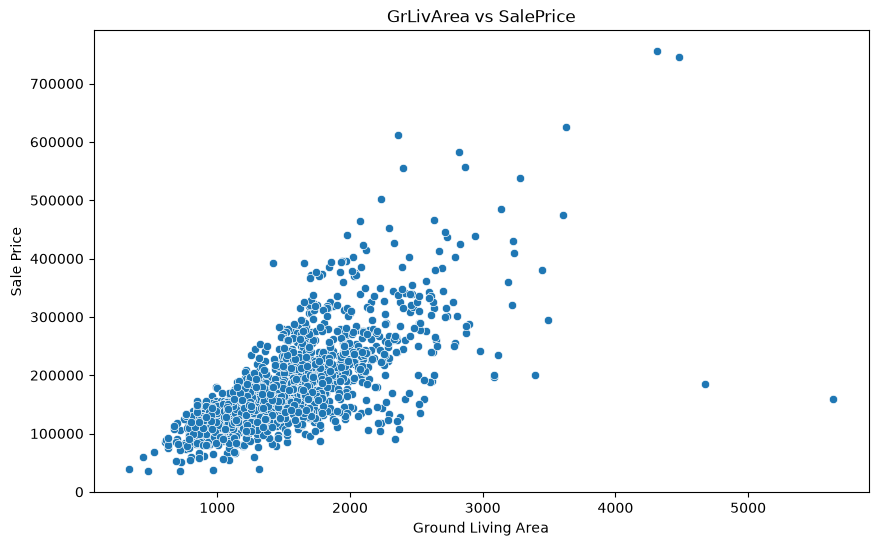

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df["GrLivArea"],
    y=df["SalePrice"]
)

plt.title("GrLivArea vs SalePrice")
plt.xlabel("Ground Living Area")
plt.ylabel("Sale Price")

plt.show()

## Relationship Between GrLivArea and SalePrice

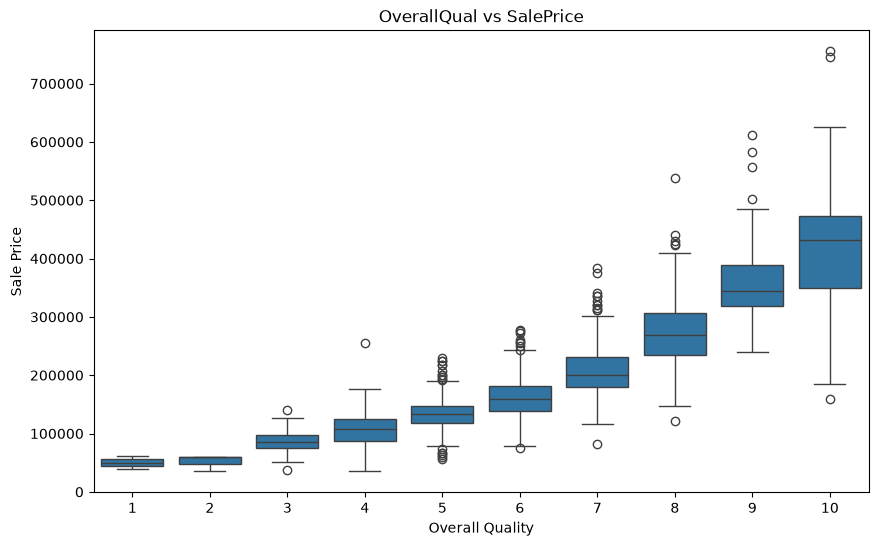

In [28]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x=df["OverallQual"],
    y=df["SalePrice"]
)

plt.title("OverallQual vs SalePrice")
plt.xlabel("Overall Quality")
plt.ylabel("Sale Price")

plt.show()

### Observation

The boxplot shows a clear positive relationship between `OverallQual` and `SalePrice`. As the overall quality rating increases, the median sale price generally increases as well. Higher quality categories also exhibit a wider range of sale prices, indicating that `OverallQual` is one of the most influential features for predicting house prices.

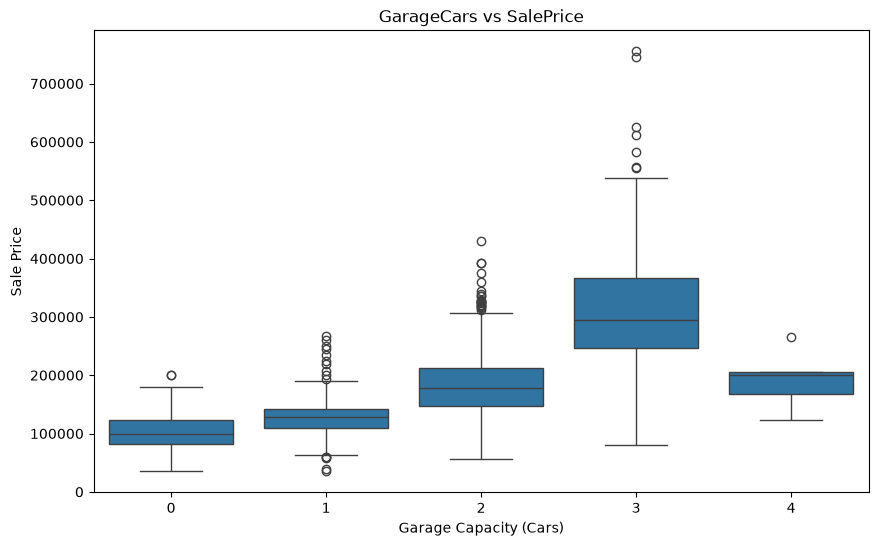

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df["GarageCars"],
    y=df["SalePrice"]
)

plt.title("GarageCars vs SalePrice")

plt.xlabel("Garage Capacity (Cars)")

plt.ylabel("Sale Price")

plt.show()

## Distribution of Important Numerical Features

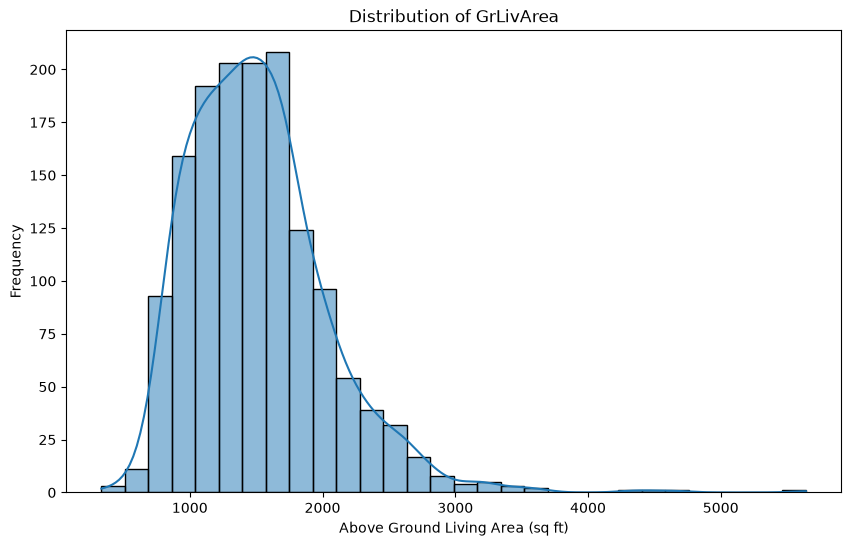

In [30]:
plt.figure(figsize=(10, 6))

sns.histplot(df["GrLivArea"], bins=30, kde=True)

plt.title("Distribution of GrLivArea")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Frequency")

plt.show()

### Distribution of LotArea

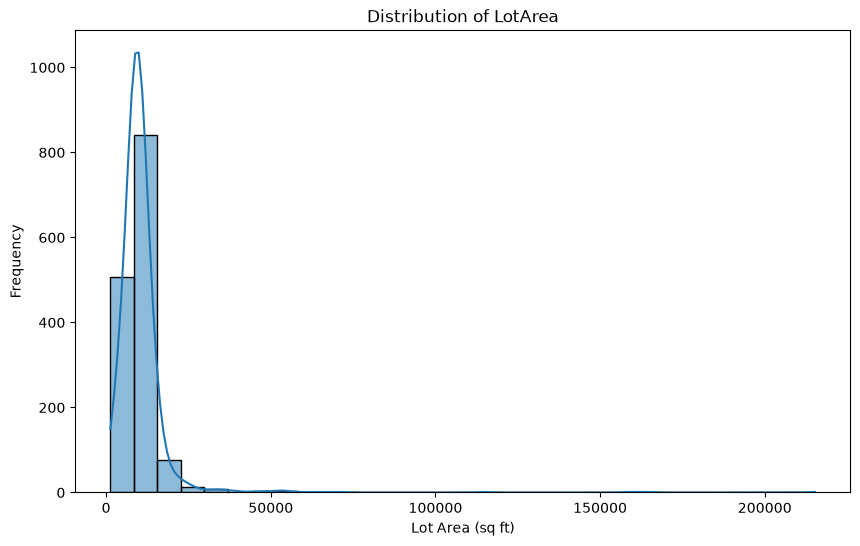

In [31]:
plt.figure(figsize=(10, 6))

sns.histplot(df["LotArea"], bins=30, kde=True)

plt.title("Distribution of LotArea")
plt.xlabel("Lot Area (sq ft)")
plt.ylabel("Frequency")

plt.show()

# Exploratory Data Analysis (EDA) Summary

## Key Findings

- The dataset contains a mix of numerical and categorical features describing residential properties.
- Missing values are present in several features and will need to be handled during preprocessing.
- The target variable (`SalePrice`) is positively skewed, with a small number of high-priced properties.
- Several high-value outliers were identified in `SalePrice`.
- Strong positive correlations were observed between `SalePrice` and features such as `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, and `TotalBsmtSF`.
- The exploratory analysis provides a clear understanding of the dataset and highlights the preprocessing steps required before machine learning model training.

# Data Preprocessing

## Missing Value Analysis

In [32]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

## Missing Value Percentage

In [33]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

In [34]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False).to_frame(
    name="Missing Percentage"
)

,Missing Percentage
PoolQC,99.52
MiscFeature,96.30
Alley,93.77
Fence,80.75
MasVnrType,59.73
FireplaceQu,47.26
LotFrontage,17.74
GarageType,5.55
GarageYrBlt,5.55
GarageFinish,5.55


### Observation

- Several columns contain missing values.
- Features such as `PoolQC`, `MiscFeature`, `Alley`, and `Fence` have more than 80% missing values.
- Many missing values represent the absence of a feature rather than incomplete data.
- Numerical columns such as `LotFrontage` and `MasVnrArea` have relatively few missing values and can be imputed later.

## Handling Missing Values – Categorical Features

In [35]:
none_columns = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2"
]

df[none_columns] = df[none_columns].fillna("None")

In [36]:
df[none_columns].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

### Observation

Missing values in columns representing the absence of a property feature were replaced with `"None"` instead of statistical values.

This preserves the semantic meaning of the data because a missing value in these columns indicates that the corresponding feature does not exist rather than representing incomplete information.

## Imputing Numerical Features

In [38]:
df[["LotFrontage", "GarageYrBlt", "MasVnrArea"]].median()

LotFrontage      69.0
GarageYrBlt    1980.0
MasVnrArea        0.0
dtype: float64

In [39]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())

df["MasVnrArea"] = df["MasVnrArea"].fillna(df["MasVnrArea"].median())

In [40]:
df[["LotFrontage", "GarageYrBlt", "MasVnrArea"]].isnull().sum()

LotFrontage    0
GarageYrBlt    0
MasVnrArea     0
dtype: int64

### Observation

Missing values in the numerical features `LotFrontage`, `GarageYrBlt`, and `MasVnrArea` were imputed using their respective median values. The median was chosen because it is less sensitive to outliers than the mean and provides a robust estimate for skewed numerical distributions.

## Imputing Remaining Categorical Features

In [41]:
df["Electrical"].mode()

0    SBrkr
Name: Electrical, dtype: str

In [42]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [43]:
df["Electrical"].isnull().sum()

np.int64(0)

In [44]:
df.isnull().sum().sum()

np.int64(872)

In [45]:
df.isnull().sum()[df.isnull().sum() > 0]

MasVnrType    872
dtype: int64

### Observation

The remaining missing value in the `Electrical` feature was replaced with the mode, as it was the only missing record in the column. A final verification confirmed that the dataset no longer contains any missing values.

In [46]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

In [47]:
df["MasVnrType"].isnull().sum()

np.int64(0)

In [48]:
df.isnull().sum().sum()

np.int64(0)

### Observation

The `MasVnrType` feature contained 872 missing values, representing houses without masonry veneer. These missing values were replaced with `"None"` to preserve the semantic meaning of the data. A final verification confirmed that the dataset contains no remaining missing values.

# Encoding Categorical Features

## Identifying Categorical Features

In [49]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(f"Number of categorical columns: {len(categorical_columns)}")

Number of categorical columns: 43


C:\Users\Mudassar Iqbal Shah\AppData\Local\Temp\ipykernel_3156\4202200905.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [50]:
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [51]:
df[categorical_columns].nunique().sort_values(ascending=False)

Neighborhood     25
Exterior2nd      16
Exterior1st      15
Condition1        9
SaleType          9
HouseStyle        8
RoofMatl          8
Condition2        8
BsmtFinType2      7
BsmtFinType1      7
GarageType        7
Functional        7
Heating           6
SaleCondition     6
GarageCond        6
FireplaceQu       6
GarageQual        6
RoofStyle         6
Foundation        6
MiscFeature       5
Fence             5
BsmtExposure      5
ExterCond         5
BsmtQual          5
BldgType          5
LotConfig         5
MSZoning          5
Electrical        5
HeatingQC         5
BsmtCond          5
ExterQual         4
LandContour       4
LotShape          4
MasVnrType        4
KitchenQual       4
PoolQC            4
GarageFinish      4
Alley             3
LandSlope         3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64

### Observation

The dataset contains multiple categorical features with varying numbers of unique categories. Some features have only two categories, while others contain many distinct values. Understanding the cardinality of each feature helps determine the most appropriate encoding strategy.

## Encoding Categorical Variables

Since most categorical features in the dataset are nominal and do not have a natural order, One-Hot Encoding will be used. This approach converts each category into a separate binary feature while avoiding the introduction of artificial numerical relationships.

In [52]:
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

In [53]:
df.shape

(1460, 261)

In [54]:
df.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


### Observation

Categorical variables were transformed using One-Hot Encoding. The original categorical columns were replaced with binary indicator columns, increasing the number of features while preserving all categorical information. The `drop_first=True` parameter was used to reduce redundancy and avoid multicollinearity.

In [55]:
df.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [56]:
df.dtypes.value_counts()

int64      258
float64      3
Name: count, dtype: int64

## Observation

Categorical variables were successfully transformed using One-Hot Encoding. All object-type columns were converted into binary numerical features. The dataset now contains only numerical data, making it suitable for machine learning algorithms.

In [57]:
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1460, 260)
y shape: (1460,)


In [59]:
y.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [60]:
X.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,0,0,0,1,0,0,0,1,0
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,0,0,0,0,1,0,0,0,1,0
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,0,0,0,1,0,0,0,1,0
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,0,0,0,1,0,0,0,0,0
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,0,0,0,0,1,0,0,0,1,0


## Feature and Target Separation

The dataset was separated into input features (`X`) and the target variable (`y`). The `SalePrice` column was removed from the feature set and stored separately as the prediction target. This prepares the dataset for model training.